<h1> Análisis y perspectivas sobre Política Monetaria </h1>

En este documento se presenta un análisis sobre politica monetaría y perspectivas sobre el nivel de tasa objetivo a final del año

In [31]:
# Librerias necesarias
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from dotenv import load_dotenv

from api_caller.banxico import Banxico_SIE
from api_caller.fed import Fred

from Forward import Forward

In [32]:
# Carga variables de un archivo .env (para almacenar el token de la API de Banxico)
load_dotenv()

# Token
BANXICO_TOKEN = os.environ.get("Banxico_Token")
FRED_TOKEN = os.environ.get("FRED_Token")

banxico_api = Banxico_SIE(BANXICO_TOKEN)
fred_api = Fred(FRED_TOKEN)

In [39]:
# Descarga de series de banxico
fecha_inicio = (pd.Timestamp.now() - pd.DateOffset(years=20)).to_period("M").to_timestamp().strftime("%Y-%m-%d")

series_dict = {'SP1':'INPC', 'SR17622':'PIB',
               'SF61745': 'Tasa_objetivo_MX',
               'SP30578': 'inflacion_anual_MX',
               'SR14139': 'Expectativas_inflacion_cierre_MX',
               'SR14194': 'Expectativas_inflacion_12_meses_MX',
               'SF17908': 'Tipo_cambio_MXN_USD',
               'SR14770': 'Expectativas_TC_MXN_USD_cierre'
               }

# Series
series_banxico = banxico_api.get_series_data(list(series_dict.keys()), start_date=fecha_inicio)

# Se ordenan las columnas, se verifica que los datos son numericos y se cambia el nombre de las series_banxico
series_banxico = series_banxico.sort_index(axis=1)
series_banxico = series_banxico.apply(pd.to_numeric, errors='coerce')
series_banxico = series_banxico.rename(columns=series_dict)

# Calculamos la media mensual de la serie en caso de tener series_banxico con mayor desagregacion
series_banxico = series_banxico.resample('MS').mean()

In [40]:
# Descarga de series de la FED
fecha_inicio = (pd.Timestamp.now() - pd.DateOffset(years=20)).to_period("M").to_timestamp().strftime("%Y-%m-%d")

series_dict = {'FEDFUNDS':'Federal_funds_effective_rate_US'}

# Series
series_fed = fred_api.get_series_data(list(series_dict.keys()), start_date=fecha_inicio)

# Se ordenan las columnas, se verifica que los datos son numericos y se cambia el nombre de las series_fed
series_fed = series_fed.sort_index(axis=1)
series_fed = series_fed.apply(pd.to_numeric, errors='coerce')
series_fed = series_fed.rename(columns=series_dict)

# Calculamos la media mensual de la serie en caso de tener series_fed con mayor desagregacion
series_fed = series_fed.resample('MS').mean()

In [41]:
# Descarga de series de la FED
fecha_inicio = (pd.Timestamp.now() - pd.DateOffset(years=5)).to_period("M").to_timestamp().strftime("%Y-%m-%d")

series_dict = {'FEDTARMD': 'Fed_funds_rate_projections_US'}

# Series
series_fed_proj = fred_api.get_series_data(list(series_dict.keys()), end_date=pd.to_datetime('2027'))

# Se ordenan las columnas, se verifica que los datos son numericos y se cambia el nombre de las series_fed
series_fed_proj = series_fed_proj.sort_index(axis=1)
series_fed_proj = series_fed_proj.apply(pd.to_numeric, errors='coerce')
series_fed_proj = series_fed_proj.rename(columns=series_dict)

# Modificamos para que se muestre a fin de año
series_fed_proj.index = series_fed_proj.index.map(lambda d: d.replace(month=12))

In [42]:
# Concatenamos en un mismo dataframe
series = pd.concat([series_banxico, series_fed], axis=1, join='outer')


# Diferencial de tasas

Con esto podemos ver la diferencia de tasas y donde se encuentra el nivel actual con respecto al historico

In [44]:
# Calculamos el diferencial de tasas
series['Diferencial_Tasa_MX_US'] = series['Tasa_objetivo_MX'] - series['Federal_funds_effective_rate_US']

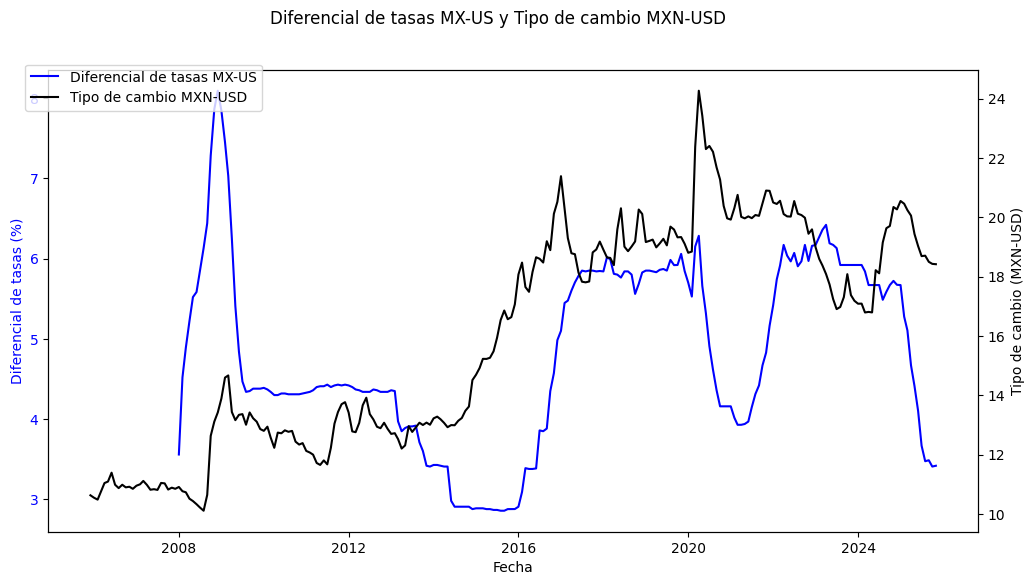

In [45]:
# Graficamos el spreaad de tasas y el tipo de cambio, en la misma grafica con dos ejes y colores diferentes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.plot(series.index, series['Diferencial_Tasa_MX_US'], color='blue', label='Diferencial de tasas MX-US')
ax2.plot(series.index, series['Tipo_cambio_MXN_USD'], color='black', label='Tipo de cambio MXN-USD')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Diferencial de tasas (%)', color='blue')
ax2.set_ylabel('Tipo de cambio (MXN-USD)', color='black')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='black')
fig.suptitle('Diferencial de tasas MX-US y Tipo de cambio MXN-USD')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()

count    215.000000
mean       4.825945
std        1.147136
min        2.860000
25%        4.060774
50%        4.430000
75%        5.840000
max        8.090000
Name: Diferencial_Tasa_MX_US, dtype: float64


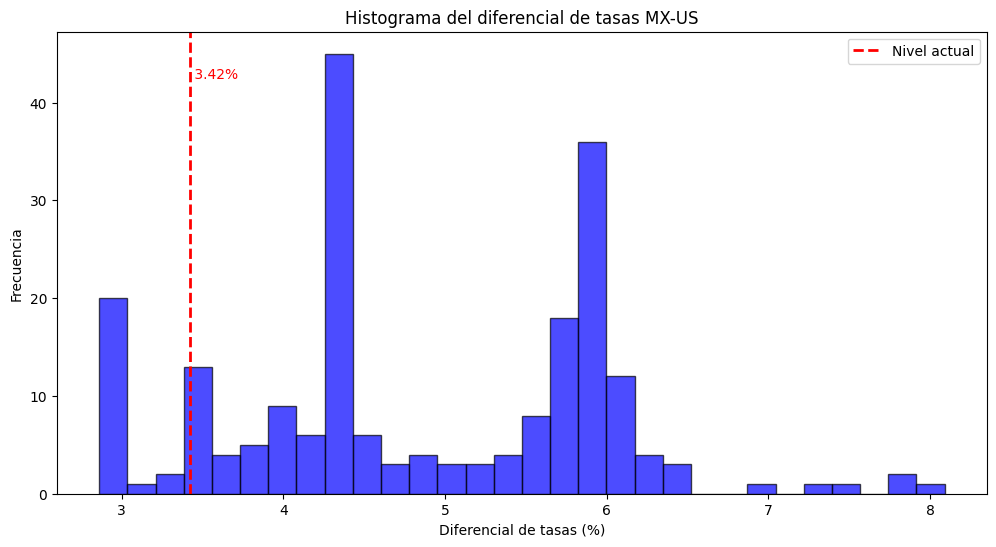

In [55]:
# Obtenemos un histograma sobre el diferencial de tasas con matplotlib, marcando el nivel actual con una linea vertical y como texto

plt.figure(figsize=(12, 6))
plt.hist(series['Diferencial_Tasa_MX_US'].dropna(), bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.axvline(series['Diferencial_Tasa_MX_US'].dropna().iloc[-1], color='red', linestyle='dashed', linewidth=2, label='Nivel actual')
plt.text(series['Diferencial_Tasa_MX_US'].dropna().iloc[-1], plt.ylim()[1]*0.9, f' {series["Diferencial_Tasa_MX_US"].dropna().iloc[-1]:.2f}%', color='red')
plt.legend()
plt.title("Histograma del diferencial de tasas MX-US")
plt.xlabel("Diferencial de tasas (%)")
plt.ylabel("Frecuencia")

print(series['Diferencial_Tasa_MX_US'].describe())

plt.show()

# Tasa real ex-ante y tasa real neutral

Con la tasa real ex-ante se puede ver en donde se encuentra la tasa actual con respecto a las expectativas de inflacion en los proximos 12 meses. Si esta en entorno restrictivo, expansivo o neutral

In [56]:
# Tasa real neutral
neutral_rate_lower_bound = 1.8
neutral_rate_median = 2.7
neutral_rate_upper_bound = 3.6


In [57]:
# Tasa real exante
series['Tasa_real_exante_MX'] = series['Tasa_objetivo_MX'] - series['Expectativas_inflacion_12_meses_MX']

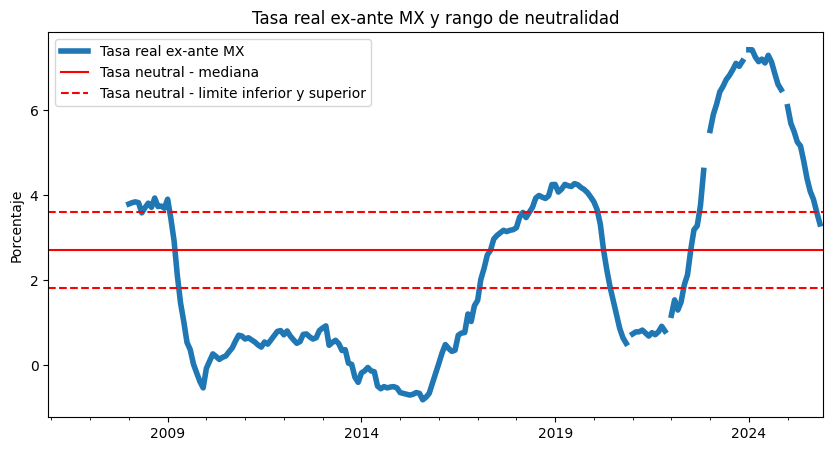

In [58]:
series['Tasa_real_exante_MX'].plot(figsize=(10, 5), label='Tasa real ex-ante MX', linewidth=4)

plt.axhline(neutral_rate_median, color='red', linestyle='-', label='Tasa neutral - mediana')
plt.axhline(neutral_rate_lower_bound, color='red', linestyle='--', label='Tasa neutral - limite inferior y superior')
plt.axhline(neutral_rate_upper_bound, color='red', linestyle='--')

plt.title('Tasa real ex-ante MX y rango de neutralidad')
plt.ylabel('Porcentaje')
plt.legend()
plt.show()

In [59]:
change_to_neutral = series['Tasa_real_exante_MX'].dropna().iloc[-1] - np.array([neutral_rate_lower_bound, neutral_rate_median, neutral_rate_upper_bound])
change_to_neutral = [-int(change/0.25)*0.25 for change in change_to_neutral][::-1]

change_to_neutral

[0.25, -0.5, -1.5]

# Paridad de tasas de interés (descubierta)

Compara las tasas de interés con expectativas del tipo de cambio futuro. 

Esto ayuda a vislumbrar el nivel de tasa que puede llegar a tener Banxico de acuerdo con los cambios esperados en el FED, tomando como equilibrio que no haya afectación en el tipo de cambio.